In [2]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from glob import glob
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from io import StringIO
import os
import shlex
from tqdm.auto import tqdm

font_files = font_manager.findSystemFonts(fontpaths='/home/vladimirnoz/Projects/Codebook_Perspectives/fonts')
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

os.chdir('/home/vladimirnoz/Projects/Codebook_Perspectives/AS_CHS_GHTS/')
sns.set_style('whitegrid')

In [4]:
tf_types = pd.read_table('/home/vladimirnoz/Projects/Codebook_Perspectives/common/tftypes.txt', names=['tf', 'type'])
tf_types = tf_types.set_index('tf').to_dict()['type']

In [5]:
asb_files = 'as_tables/*/ASB_motifs/*.tsv'
peak_files = '/home/vladimirnoz/Projects/Codebook_Perspectives/peaks/chipseq+ghtselex'
top_files = '/home/vladimirnoz/Projects/Codebook_Perspectives/TOPs/TOPs'

In [11]:
from importlib import reload
from functools import reduce

def intersect_ase(ase_df, interval_path, tag, only_tag=True):
    cmd = f'bedtools intersect -a stdin -b {interval_path} -wa'
    cmd = shlex.split(cmd)
    df = ase_df.copy()
    table_text = subprocess.run(cmd,
                                capture_output=True, text=True,
                                input=df.to_csv(sep='\t', index=False)
                               ).stdout
    df_intersected = pd.read_table(StringIO(table_text), names=df.columns)
    cols_to_join = ['#chr', 'start', 'end', 'id']
    df_intersected = df_intersected[cols_to_join]
    df_intersected[tag] = True
    df = df.merge(df_intersected, on=cols_to_join, how='left').drop_duplicates()
    df[tag] = ~df[tag].isna()
    if only_tag:
        return df[[*cols_to_join, tag]]
    else:
        return df(base)

tables = []
for file in tqdm(glob(asb_files)):
    tf = os.path.basename(file)[:-4]
    if not os.path.isfile(f'{top_files}/{tf}.bed'):
        continue

    tf_type = tf_types[tf]
    df = pd.read_table(file)
    #df = df.query('fdr_comb_pval < 0.05')
    df['tf'] = tf
    df['tf_type'] = tf_type
    top_path = f'{top_files}/{tf}.bed'
    tags = [
        intersect_ase(df, f'{top_files}/{tf}.bed', 'top'), 
        #intersect_ase(df, f'{ctop_files}/{tf}.bed', 'ctop'),
        intersect_ase(df, f'{peak_files}/{tf}.bed', 'peak'),
        ]
    cols_to_join = ['#chr', 'start', 'end', 'id']
    tags = reduce(lambda df1, df2: df1.merge(df2, on=cols_to_join, how='outer'), tags)
    tables.append(df.merge(tags, on=cols_to_join, how='inner'))

  0%|          | 0/333 [00:00<?, ?it/s]

In [12]:
df = pd.concat(tables, ignore_index=True)
df.query('fdr_comb_pval < 0.05 & top').groupby('id').count().sort_values(by='start', ascending=False).head(10)

,#chr,start,end,mean_bad,max_cover,ref,alt,n_reps,ref_comb_es,alt_comb_es,...,alt_motif_pos,alt_motif_orient,ref_motif_pval,alt_motif_pval,motif_fc,motif_conc,tf,tf_type,top,peak
id,,,,,,,,,,,,,,,,,,,,,
rs147487727,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
rs2764408,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
rs1879138,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
rs12450429,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
rs111739624,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
rs4907379,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
rs7160649,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
rs75924914,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
rs2955626,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


In [13]:
df.query('id == "rs11670878" & fdr_comb_pval < 0.05')

,#chr,start,end,mean_bad,id,max_cover,ref,alt,n_reps,ref_comb_es,...,alt_motif_pos,alt_motif_orient,ref_motif_pval,alt_motif_pval,motif_fc,motif_conc,tf,tf_type,top,peak
98015,chr19,53746504,53746505,1.0,rs11670878,105,C,T,7,1.479500,...,-26,direct,7.409369e-08,1.965847e-07,-1.407729,Concordant,CTCF,Control,True,True
150197,chr19,53746504,53746505,1.0,rs11670878,719,C,T,2,0.363754,...,-5,revcomp,1.173149e-04,2.964520e-04,-1.337412,Concordant,ZNF732,Codebook TF,True,True


415
[np.float64(2.380307930970343e-10), np.float64(8.256883704102122e-06), np.float64(1.5778792919753474e-32), np.float64(1.2512981045593686e-16)]
Rectangle(xy=(0, 0), width=0, height=0, angle=0)
Rectangle(xy=(0, 0), width=0, height=0, angle=0)
Rectangle(xy=(0, 0), width=0, height=0, angle=0)


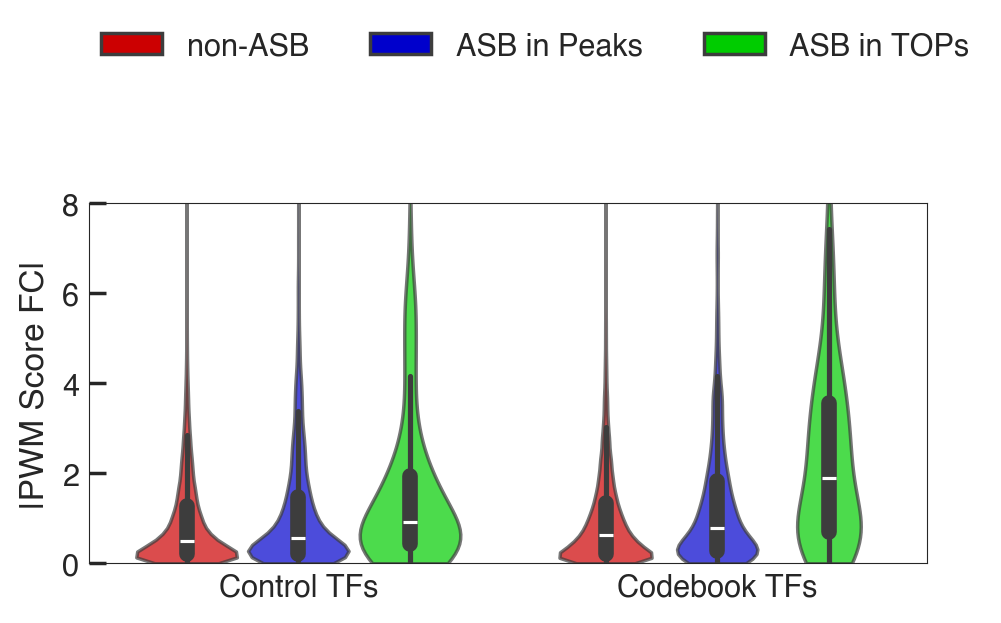

In [16]:
from scipy.stats import mannwhitneyu

def compare(df1, df2, tftype):
    df1 = df1.query(f'tf_type == "{tftype}"').copy()
    df2 = df2.query(f'tf_type == "{tftype}"').copy()
    u, p = mannwhitneyu(df1['motif_fc'], df2['motif_fc'])
    return p


fig, ax = plt.subplots(dpi=200, figsize=(5, 2.5))
for a in ['top', 'bottom', 'right', 'left']:
    ax.spines[a].set_linewidth(0.4)
sns.set(font_scale=1, style="ticks", font="helvetica")
plt.tight_layout(h_pad=1)
mini_dfs = []
hue_order = 'nonase peak top'.split()
tags_order = ['non-ASB', 'ASB in Peaks', 'ASB in TOPs']
palette = ['#CC0001', '#00C', '#0C0']
motif_fc_outlier_thr = 8
for i, tag in enumerate(hue_order):
    if tag == 'top':
        mini_df = df.query('fdr_comb_pval < 0.05 & top').copy()
        print(len(mini_df))
        mini_df['tag'] = tags_order[i]
    if tag == 'peak':
        mini_df = df[df['peak'] * (~df['top'])].query('fdr_comb_pval < 0.05').copy()
        mini_df['tag'] = tags_order[i]
    if tag == 'nonase':
        mini_df = df.query('fdr_comb_pval > 0.5').copy()
        mini_df['tag'] = tags_order[i]
    mini_df['motif_fc'] = mini_df['motif_fc'].abs()
    mini_dfs.append(mini_df)
order = ['Control', 'Codebook TF']
pvalues = []
for tftype in order:
    pvalues.append(compare(mini_dfs[0], mini_dfs[1], tftype))
    pvalues.append(compare(mini_dfs[1], mini_dfs[2], tftype))
print(pvalues)
maxi_df = pd.concat(mini_dfs, ignore_index=True)

y_var = ['comb_es', 'Effect Size']
y_var = ['motif_fc', '|PWM Score FC|']
plt.ylim([0, 8])
viol = sns.violinplot(
    data=maxi_df, 
    x='tf_type', 
    y=y_var[0], 
    hue='tag',
    ax=ax,
    order=order,
    hue_order=tags_order,
    gap=0.1,
    zorder=2,
    #fliersize=0,
    cut=0,
    palette=palette,
    saturation=1,
)
for violin in (viol.collections):
    violin.set_alpha(0.7)
    bbox = violin.get_tightbbox()
    

for patch, pvalue in zip(viol.patches, pvalues):
    print(patch)
plt.xticks([0, 1], labels=['Control TFs', 'Codebook TFs'])
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in", length=0)
ax.set_ylabel(y_var[1])
ax.set_xlabel(None)
plt.legend(frameon=False, loc=[0, 1.36], ncol=3)
plt.savefig('figures/peaks_es.pdf', bbox_inches='tight')

In [16]:
maxi_df[['tf', 'tf_type']].drop_duplicates()['tf_type'].value_counts()

tf_type
Codebook TF    85
Control        32
Name: count, dtype: int64